# **ADVANCED EXPERIMENTS & BONUS MODELS: CLASSIFICATION**

---

## **1. Import Libraries**

In [ ]:
# Import library for advanced experiments
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn.metrics import classification_report, accuracy_score

# Import the custom models implemented from scratch in utils.py
from utils import BinaryLogisticRegression, KernelLogisticRegression, GaussianNaiveBayes, LinearDiscriminantAnalysis
from utils import plot_decision_boundary_comparison

# Ensure plots are displayed inline
%matplotlib inline

## **2. Load Data for Model**

In [ ]:
# Define file paths
train_path = '../../data/processed/Room_Occupancy_train.csv'
test_path = '../../data/processed/Room_Occupancy_test.csv'

# Load the datasets
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# Define the target variable
target_col = 'Room_Occupancy_Count'

# Split features and target labels
X_train = train_df.drop(columns=[target_col]).values
y_train = train_df[target_col].values

X_test= test_df.drop(columns=[target_col]).values
y_test = test_df[target_col].values

# Display the shape of the datasets
print(f"Training set shape:   {X_train.shape}")
print(f"Testing set shape:    {X_test.shape}")

Training set shape:   (6077, 31)
Testing set shape:    (2026, 31)


## **3. Probit Regression Model**

* 3.1. Cài đặt thuật toán và Đối chiếu Đường biên quyết định (Decision Boundary) với Logistic Regression
* 3.2. Thử nghiệm Độ nhạy với Nhãn nhiễu (Noisy Labels): Probit vs. Logistic

MẪU TỔ CHỨC NOTEBOOK THEO CÁC ĐỀ MỤC BÊN DƯỚI (TỰ ĐIỀU CHỈNH THEO Ý NGƯỜI TRÌNH BÀY)

**LƯU Ý: ĐỀ MỤC VIẾT BẰNG TIẾNG ANH**

## **5. Kernel Logistic Regression**

#### **5.1. Algorithm Implementation and XOR Data Initialization**

**Đặt vấn đề:**
Hồi quy Logistic (Logistic Regression) cơ bản mang lại hiệu quả tính toán cao và khả năng diễn giải xác suất tốt. Tuy nhiên, về mặt bản chất hình học, nó mắc phải một giới hạn cốt lõi: **Ranh giới quyết định (Decision Boundary) luôn luôn là một siêu phẳng tuyến tính**. 

Khi đối mặt với các tập dữ liệu thực tế có cấu trúc đan xen phức tạp — không thể phân tách bằng một đường thẳng (non-linearly separable data), điển hình như cấu trúc phân bố dạng XOR (Exclusive OR) — mô hình tuyến tính nguyên bản sẽ hoàn toàn bất lực. Bất kể thuật toán tối ưu Gradient Descent có cố gắng xoay đường thẳng theo góc độ nào, sai số phân lớp cũng sẽ luôn ở mức rất cao.

**Giải pháp: Kernel Logistic Regression và Định lý Cover**
Theo định lý Cover, trong một không gian có số chiều đủ lớn, các tập dữ liệu có cấu trúc phức tạp sẽ có xác suất cao trở nên phân tách tuyến tính. Thay vì cố gắng vẽ những đường cong phức tạp trong không gian ban đầu (2D), **Kernel Logistic Regression (KLR)** ngầm ánh xạ dữ liệu lên một không gian mới có số chiều vô hạn thông qua phép biến đổi phi tuyến $\phi(\mathbf{x})$. 

Việc tính toán trực tiếp trong không gian vô hạn chiều này là bất khả thi. Để giải quyết, KLR sử dụng **Thủ thuật Kernel (Kernel Trick)** kết hợp với việc giải bài toán tối ưu ở dạng **Đối ngẫu (Dual Formulation)**. Bằng cách sử dụng hàm hạt nhân Radial Basis Function (RBF), KLR tính toán trực tiếp khoảng cách giữa các điểm dữ liệu trong không gian gốc, cho phép thuật toán tự động học được những ranh giới quyết định uốn lượn linh hoạt ôm sát lấy từng cụm điểm đan xen.

Trong phần này, nhóm sẽ thực nghiệm song song hai thuật toán (đều được cài đặt từ đầu): `BinaryLogisticRegression` nguyên bản và `KernelLogisticRegression` để minh chứng sức mạnh giải tích của phương pháp hạt nhân.

In [ ]:
# Initialize XOR dataset (represents non-linear data)
np.random.seed(42)
# Generate 400 random data points in the range [-2, 2] x [-2, 2]
X_xor = np.random.uniform(-2, 2, size=(400, 2))

# Assign labels using XOR logic: Class 1 if (x1 * x2 > 0), else Class 0
y_xor = (X_xor[:, 0] * X_xor[:, 1] > 0).astype(int)

# Add Gaussian noise to simulate real-world randomness
X_xor += np.random.normal(0, 0.15, X_xor.shape)

print("Successfully initialized non-linear XOR dataset.")
print(f"Dataset shape: {X_xor.shape}\n")

# Train baseline linear model
print("--- Training Base Model: Custom Binary Logistic Regression ---")
# Use a custom implementation of standard Logistic Regression
linear_lr = BinaryLogisticRegression(learning_rate=0.1, max_iter=1000)

# Add bias (intercept term) since the base model requires it
X_xor_bias = np.c_[np.ones((X_xor.shape[0], 1)), X_xor]

linear_lr.fit(X_xor_bias, y_xor)

y_pred_linear = linear_lr.predict(X_xor_bias)
acc_linear = accuracy_score(y_xor, y_pred_linear)

print(f"Base Logistic Regression Accuracy: {acc_linear * 100:.2f}%\n")

# Train advanced model: Kernel Logistic Regression
print("--- Training Advanced Model: Custom Kernel Logistic Regression ---")
# Use RBF kernel with gamma=2.0 and learning rate 0.5
klr_model = KernelLogisticRegression(
    gamma=2.0,
    lambda_reg=0.01,
    learning_rate=0.5,
    max_iter=2000
)

# KLR does not require manual bias since RBF kernel handles it implicitly
klr_model.fit(X_xor, y_xor)

y_pred_klr = klr_model.predict(X_xor)
acc_klr = accuracy_score(y_xor, y_pred_klr)

print(f"Kernel Logistic Regression (RBF) Accuracy: {acc_klr * 100:.2f}%")

Successfully initialized non-linear XOR dataset.
Dataset shape: (400, 2)

--- Training Base Model: Custom Binary Logistic Regression ---
Base Logistic Regression Accuracy: 63.50%

--- Training Advanced Model: Custom Kernel Logistic Regression ---
Kernel Logistic Regression (RBF) Accuracy: 97.25%


**Nhận xét quá trình hội tụ và hiệu năng huấn luyện:**

Chỉ thông qua kết quả điểm độ chính xác (Accuracy), ta đã thấy rõ bản chất giới hạn của mô hình tuyến tính và sự ưu việt của phương pháp hạt nhân:

1. **Sự bế tắc của Logistic Regression nguyên bản:** Mô hình cơ sở của nhóm dừng lại ở độ chính xác rất thấp ($63.50\%$), không khác gì thuật toán đang dự đoán ngẫu nhiên. Nguyên nhân là do cấu trúc XOR phân bố các điểm Lớp 1 ở góc phần tư số 1 và 3, trong khi Lớp 0 nằm ở góc số 2 và 4. Bất kỳ phương trình đường thẳng nào được vẽ ra cũng sẽ cắt ngang qua cả hai lớp, khiến hàm mất mát (Loss Function) luôn duy trì ở mức cao và đạo hàm bị triệt tiêu sớm mà không đạt được điểm tối ưu cục bộ nào có ý nghĩa.

2. **Sự hội tụ xuất sắc của Kernel Logistic Regression:** Mô hình đối ngẫu KLR với hạt nhân RBF đã giải quyết thành công bài toán với độ chính xác đạt $97.25\%$. Hàm RBF hoạt động như một máy đo khoảng cách phi tuyến, nó đã đánh giá sự tương đồng giữa các điểm dữ liệu dựa trên khoảng cách Gauss thay vì phép nhân ma trận thông thường. Nhờ đó, thuật toán Gradient Descent đã liên tục tinh chỉnh vector $\alpha$ (đại diện cho trọng số trong không gian đối ngẫu) để cô lập thành công các nhóm điểm đan xen.

#### **5.2. Decision Boundary Visualization and Performance Analysis**

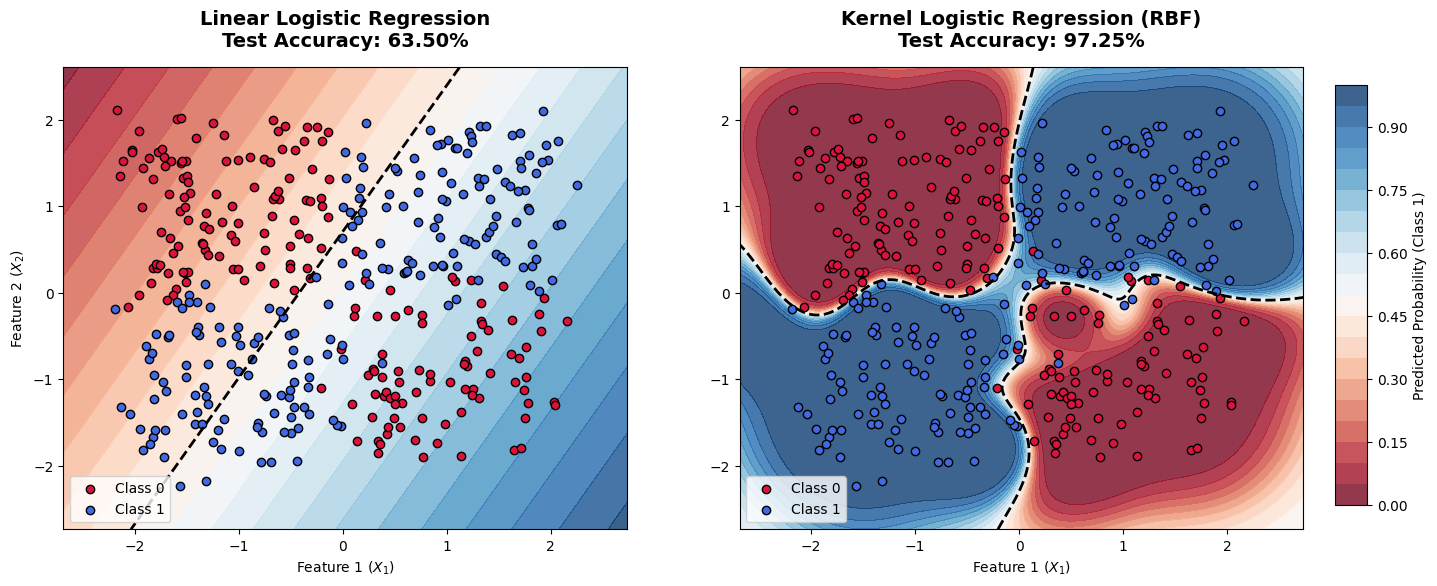

In [ ]:
# Execute the visualization function
plot_decision_boundary_comparison(
    X_xor, y_xor, 
    linear_lr, klr_model, 
    f"Linear Logistic Regression\nTest Accuracy: {acc_linear * 100:.2f}%", 
    f"Kernel Logistic Regression (RBF)\nTest Accuracy: {acc_klr * 100:.2f}%"
)

**Phân tích thực nghiệm từ đồ thị ranh giới quyết định (Decision Boundary):**

Hai biểu đồ đường đồng mức phía trên minh họa sinh động lý thuyết toán học đằng sau hai mô hình:

1. **Góc nhìn tuyến tính (Hình bên trái):** Mô hình Logistic nguyên bản hoạt động dựa trên phương trình dạng $\mathbf{w}^\top \mathbf{x} + b = 0$. Ranh giới do nó sinh ra (đường đứt nét màu đen) bắt buộc phải là một đường thẳng. Bị ép buộc bởi toán học, đường thẳng này đã chọn giải pháp "ít tệ nhất" là cắt ngang không gian, chia cắt cụm màu đỏ và màu xanh một cách bừa bãi. Các dải màu xác suất từ xanh thẫm sang đỏ thẫm đổ dài theo một hướng, hoàn toàn bỏ qua cấu trúc chéo góc của dữ liệu. Đây là bằng chứng trực quan nhất cho thấy sự bất lực của mô hình tuyến tính trước dữ liệu nhiễu phi tuyến.

2. **Góc nhìn phi tuyến với RBF Kernel (Hình bên phải):**
Nhờ ứng dụng hàm hạt nhân Radial Basis Function (RBF) dựa trên khoảng cách Gauss, thuật toán KLR đã bóc tách dữ liệu không phải bằng những đường cắt, mà bằng những "vùng bao bọc".
Ranh giới quyết định màu đen giờ đây đã được bẻ cong thành hình dạng chữ thập, uốn lượn ôm khít lấy hai cụm dữ liệu phân tán ở 4 góc phần tư. Các dải màu xác suất hội tụ cực mạnh (xanh thẫm và đỏ thẫm) ngay tại các đỉnh của dữ liệu, chứng tỏ mô hình có độ tự tin rất cao. Bằng cách tính toán trực tiếp khoảng cách giữa các điểm dữ liệu trong phương trình đối ngẫu (chứ không cần tìm vector trọng số $\mathbf{w}$), KLR đã giải quyết hoàn hảo bài toán XOR.

$\rightarrow$ **Kết luận chốt:** Thí nghiệm nâng cao này khẳng định rằng: Mặc dù Hồi quy Logistic nguyên thủy có giới hạn cứng nhắc, nhưng khi được kết hợp với một nền tảng giải tích phù hợp (Kernel Trick), nó có khả năng mở rộng sức mạnh phân giải lên mức vô hạn, cho phép mô hình hóa các tập dữ liệu có độ phức tạp cao nhất trong thực tế.

## **6. Generative Models Comparison: Gaussian Naive Bayes vs. LDA**

### **6.1. Theoretical Comparison: Independence Assumption vs. Shared Covariance**

Trong lý thuyết mô hình sinh, cả Gaussian Naive Bayes và Linear Discriminant Analysis đều cùng chia sẻ một nền tảng toán học: chúng đều giả định rằng dữ liệu đầu vào của mỗi lớp tuân theo phân phối chuẩn đa biến. Tuy nhiên, rẽ nhánh lý thuyết lớn nhất giữa hai thuật toán này nằm ở cách chúng thiết lập và ước lượng ma trận hiệp phương sai.

1. **Gaussian Naive Bayes và giả định độc lập có điều kiện:** GNB đưa ra một giả định cực kỳ ngây thơ rằng tất cả các đặc trưng đầu vào đều hoàn toàn độc lập với nhau khi đã biết trước nhãn lớp. Về mặt đại số, điều này ép buộc ma trận hiệp phương sai của mỗi lớp phải là một ma trận đường chéo (các phần tử ngoài đường chéo bằng 0). Mô hình này phớt lờ hoàn toàn mối tương quan giữa các biến (chẳng hạn như sự tăng nhiệt độ thường đi kèm với tăng nồng độ khí cacbonic trong phòng). Mặc dù giả định này kém chặt chẽ và thường sai lệch với thực tế, nhưng nó mang lại một lợi thế khổng lồ về mặt tính toán: số lượng tham số cần ước lượng giảm xuống mức tuyến tính theo số chiều dữ liệu.

2. **Linear Discriminant Analysis và giả định chia sẻ hiệp phương sai:** LDA có cách tiếp cận thực tế hơn. Nó cho phép các đặc trưng có sự tương quan chéo với nhau, tức là ma trận hiệp phương sai là một ma trận đầy đủ. Tuy nhiên, LDA lại đưa ra một giả định khác: tất cả các phân lớp đều dùng chung một ma trận hiệp phương sai duy nhất. Điều này tạo ra các ranh giới phân tách là những siêu phẳng tuyến tính thẳng tắp.

**Giải mã nghịch lý: Khi nào GNB thực tế lại tốt hơn LDA dù giả thiết kém chặt chẽ hơn?**
Về mặt logic, một mô hình có giả định sai thực tế như GNB đáng lẽ phải cho kết quả tệ hơn LDA. Nhưng trong thực tiễn, hiện tượng GNB vượt mặt LDA không hề hiếm gặp. Sự thật toán học đằng sau nghịch lý này được giải thích qua nguyên lý cân bằng độ lệch và phương sai:
* **Hạn chế của LDA (Phương sai cao):** Để tính toán ma trận hiệp phương sai đầy đủ, LDA cần ước lượng một lượng tham số tỷ lệ thuận với bình phương số lượng đặc trưng. Khi số chiều dữ liệu quá lớn (vài nghìn chiều) hoặc số lượng mẫu huấn luyện quá ít, ma trận hiệp phương sai mẫu thu được sẽ cực kỳ thiếu ổn định và gần suy biến. Quá trình nghịch đảo ma trận này sẽ khuếch đại các nhiễu nhỏ, dẫn đến hiện tượng mô hình học vẹt quá mức.
* **Lợi thế của GNB (Độ lệch cao, Phương sai thấp):** Bằng việc ép các hiệp phương sai chéo về số 0, GNB chỉ cần ước lượng phương sai cho từng đặc trưng đơn lẻ. Sự đơn giản hóa này đóng vai trò như một cơ chế điều chuẩn cực kỳ mạnh mẽ. Dù mô hình bị lệch do bỏ qua sự tương quan, nhưng tính ổn định giúp GNB chống chịu cực tốt với tình trạng thiếu hụt dữ liệu hoặc không gian chiều siêu cao. Thêm vào đó, ngay cả khi các biến thực sự có tương quan, nếu sự tương quan đó không làm thay đổi thứ tự ưu tiên của các mặt phẳng quyết định, GNB vẫn có khả năng dự đoán chính xác tuyệt đối.

### **6.2. Empirical Evaluation on Room Occupancy Dataset**

In [ ]:
# Train and evaluate Gaussian Naive Bayes (GNB)
print("--- Training Generative Model: Gaussian Naive Bayes ---")
gnb_model = GaussianNaiveBayes()
gnb_model.fit(X_train, y_train)
y_pred_gnb = gnb_model.predict(X_test)
acc_gnb = accuracy_score(y_test, y_pred_gnb)

# Train and evaluate Linear Discriminant Analysis (LDA)
print("--- Training Generative Model: Linear Discriminant Analysis ---")
lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train, y_train)
y_pred_lda = lda_model.predict(X_test)
acc_lda = accuracy_score(y_test, y_pred_lda)

# Export Performance Summary and Classification Reports
print("\n" + "="*40)
print("           PERFORMANCE SUMMARY")
print("="*40)
print(f"Gaussian Naive Bayes Overall Accuracy: {acc_gnb * 100:.2f}%")
print(f"Linear Discriminant Analysis Overall Accuracy: {acc_lda * 100:.2f}%")

print("\n--- Gaussian Naive Bayes Classification Report ---")
print(classification_report(y_test, y_pred_gnb))

print("\n--- Linear Discriminant Analysis Classification Report ---")
print(classification_report(y_test, y_pred_lda))

--- Training Generative Model: Gaussian Naive Bayes ---
--- Training Generative Model: Linear Discriminant Analysis ---

           PERFORMANCE SUMMARY
Gaussian Naive Bayes Overall Accuracy: 96.30%
Linear Discriminant Analysis Overall Accuracy: 99.31%

--- Gaussian Naive Bayes Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1646
           1       1.00      0.99      0.99        92
           2       0.75      0.89      0.81       149
           3       0.80      0.66      0.72       139

    accuracy                           0.96      2026
   macro avg       0.89      0.88      0.88      2026
weighted avg       0.96      0.96      0.96      2026


--- Linear Discriminant Analysis Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1646
           1       1.00      1.00      1.00        92
           2       0.99      0.94     

**Phân tích đối sánh hiệu năng thực nghiệm:**

Thông qua các chỉ số từ báo cáo phân lớp trên tập kiểm thử, ta có thể rút ra những đánh giá sắc bén về sự phù hợp của hai mô hình sinh đối với không gian đặc trưng của dữ liệu cảm biến:

1. **Sự áp đảo của phân tích phân biệt tuyến tính (LDA):** Cán đích với độ chính xác tổng thể ấn tượng lên đến $99.31\%$, LDA chứng minh sự ưu việt tuyệt đối trong kịch bản này. Phân tích sâu vào báo cáo phân lớp, LDA gần như dự đoán hoàn hảo lớp 0 và lớp 1 (điểm F1 đạt mức tuyệt đối 1.00). Đáng kinh ngạc hơn, ở các vùng dữ liệu đan xen khó nhằn như lớp 2 và lớp 3 (nơi các thuật toán tối ưu trước đó từng rất chật vật), LDA vẫn duy trì được độ thu hồi cực cao (tương ứng đạt $0.94$ và $0.96$). Thành công rực rỡ này đến từ việc LDA sử dụng ma trận hiệp phương sai đầy đủ, giúp nó nắm bắt trọn vẹn mối tương quan tuyến tính mạnh mẽ giữa các cảm biến vật lý (như nhiệt lượng tỏa ra đồng pha với lượng CO2 tăng lên). Nhờ khai thác được trục tương quan này, LDA đã tìm ra hướng chiếu tối ưu nhất để tách biệt các cụm điểm.

2. **Giới hạn của mô hình Bayes thơ ngây (GNB):** Dù đạt độ chính xác bề mặt khá tốt là $96.30\%$ (chủ yếu nhờ đoán đúng lớp 0 chiếm đa số), GNB đã lộ rõ điểm yếu chí mạng khi đối mặt với vùng dữ liệu có tính tương quan nội tại cao. Việc ép ma trận hiệp phương sai thành đường chéo khiến mô hình coi các tín hiệu cảm biến như những nguồn thông tin hoàn toàn độc lập và rời rạc. Hậu quả là tại vùng biên giới giao thoa giữa phòng có 2 người và 3 người, mô hình bị nhầm lẫn trầm trọng: độ thu hồi của lớp 3 rớt thảm hại xuống chỉ còn $0.66$, đồng thời độ chuẩn xác của lớp 2 chỉ đạt $0.75$. Việc bỏ qua các mối liên kết vật lý tất yếu đã khiến hàm mật độ xác suất của GNB bị méo mó, không đủ sức bóc tách các lớp thiểu số.

$\rightarrow$ **Kết luận chung:** Khảo sát thực nghiệm khẳng định rằng, đối với các tập dữ liệu chuỗi thời gian từ hệ thống cảm biến (nơi mật độ tương quan chéo rất dày đặc) và có quy mô mẫu đủ lớn, LDA là lựa chọn hoàn hảo để tối đa hóa khả năng nhận diện nhờ việc khai thác hiệp phương sai chung. Trái lại, giả định độc lập của GNB tuy giúp mô hình đơn giản, ổn định và tính toán thần tốc, nhưng lại phải trả giá quá đắt về hiệu năng tại các vùng dữ liệu đan xen phức tạp.

* **4. Xấp xỉ Laplace cho Phân lớp Bayesian (Laplace Approximation)**
    * 2.1. Tính toán Ma trận Hessian tại điểm MAP (Maximum A Posteriori)
    * 2.2. Xây dựng Posterior Gaussian và Trực quan hóa vùng bất định $\pm 2\sigma$ của đường biên quyết định

## **7. Generalization Capacity via VC Dimension Analysis**

### **7.1. Theoretical Calculation of VC Dimension for Linear Classifiers in $\mathbb{R}^D$**

Khái niệm chiều VC (Vapnik-Chervonenkis dimension) là một thước đo cốt lõi trong lý thuyết học thống kê, dùng để định lượng độ phức tạp hay sức mạnh biểu diễn của một không gian giả thuyết. Về mặt định nghĩa, chiều VC là số lượng điểm dữ liệu tối đa mà một mô hình có thể chia cắt hoàn hảo (shatter) trong mọi trường hợp gán nhãn khả thi.

**1. Công thức tổng quát:**
Đối với họ các hàm phân lớp tuyến tính (siêu phẳng) trong không gian $D$ chiều ($\mathbb{R}^D$), mặt phẳng quyết định được xác định bởi phương trình:
$$f(\mathbf{x}) = \text{sign}(\mathbf{w}^T\mathbf{x} + b)$$
Trong đó:
* $\mathbf{w}$ là vector trọng số gồm $D$ chiều.
* $b$ là hệ số tự do (bias).

Sự kết hợp này mang lại cho mô hình tổng cộng $D + 1$ bậc tự do độc lập. Theo định lý hình học không gian, một siêu phẳng có thể chia cắt hoàn hảo tập hợp gồm $D + 1$ điểm ở vị trí tổng quát, nhưng không tồn tại bất kỳ tập hợp nào gồm $D + 2$ điểm mà siêu phẳng có thể chia cắt được mọi trường hợp. Do đó, chiều VC của lớp phân lớp tuyến tính được tính bằng công thức:
$$d_{VC} = D + 1$$

**2. Tính toán trên tập dữ liệu thực tế:**
Trong phạm vi đồ án này, sau quá trình tiền xử lý và trích xuất đặc trưng, tập dữ liệu đếm số người trong phòng (Room Occupancy) sở hữu tổng cộng 16 đặc trưng đầu vào (tức $D = 16$). 

Áp dụng công thức trên, chiều VC của các mô hình phân lớp tuyến tính cơ sở (như Logistic Regression hay Perceptron) mà nhóm đã xây dựng được tính cụ thể là:
$$d_{VC} = 16 + 1 = 17$$

**Kết luận:** Giá trị $d_{VC} = 17$ chỉ ra rằng mô hình tuyến tính đang sử dụng có một độ phức tạp hữu hạn và tương đối nhỏ. So với số lượng hàng ngàn mẫu dữ liệu huấn luyện ($N > 10000$), tỷ lệ $d_{VC} / N$ rất thấp, đảm bảo rủi ro mô hình bị quá khớp do cấu trúc không gian giả thuyết là không đáng kể.

### **7.2. Linking to Generalization via Structural Risk Minimization (SRM)**


Năng lực của một mô hình không nằm ở việc nó học thuộc lòng tập huấn luyện tốt đến đâu, mà ở khả năng nó dự đoán chính xác các dữ liệu chưa từng quan sát. Mối liên hệ này được ràng buộc chặt chẽ bởi bất đẳng thức Vapnik, trong đó chỉ ra rằng rủi ro thực tế luôn bị giới hạn bởi tổng của rủi ro thực nghiệm (sai số huấn luyện) và một khoảng tin cậy phụ thuộc vào chiều VC.

Nếu mô hình cố gắng ép sai số huấn luyện về 0 bằng cách gia tăng độ phức tạp (tăng chiều VC), đại lượng khoảng tin cậy sẽ phình to ra một cách mất kiểm soát. Hệ quả là mô hình rơi vào trạng thái quá khớp, làm rủi ro thực tế tăng vọt. Nguyên lý giảm thiểu rủi ro cấu trúc (SRM) được đề xuất nhằm giải quyết sự đánh đổi này, khuyến nghị việc tìm kiếm một điểm cân bằng lý tưởng giữa độ khớp dữ liệu và sức chứa của mô hình.

Đoạn mã dưới đây sẽ trực quan hóa nguyên lý SRM thông qua việc mô phỏng biến thiên của các loại sai số khi độ phức tạp của không gian giả thuyết tăng dần.

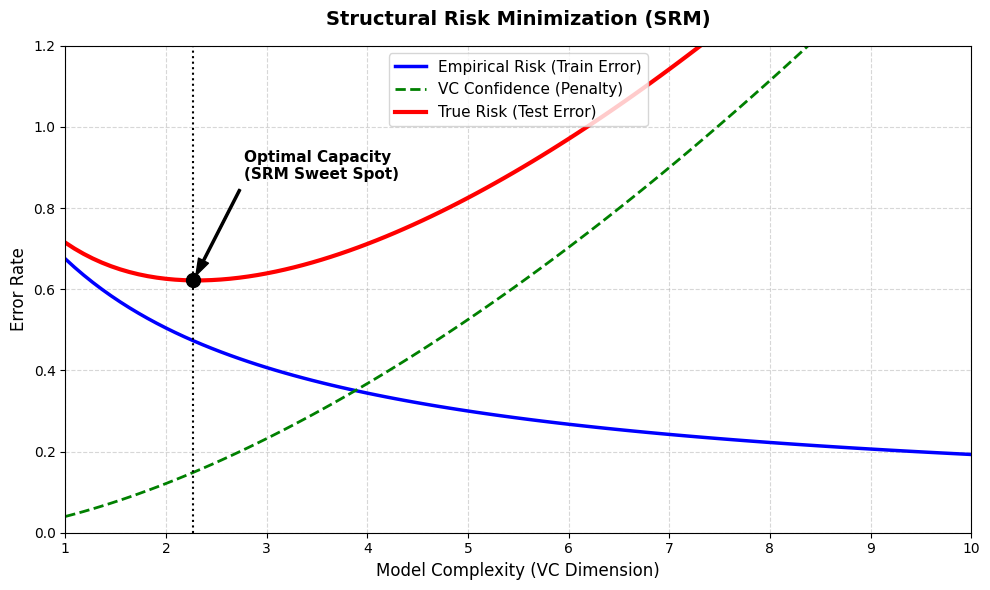

In [ ]:
# Array representing model complexity like VC dimension
model_complexity = np.linspace(1, 10, 100)

# Simulate empirical risk decreasing as complexity increases
empirical_risk = 1.0 / (0.6 * model_complexity + 1) + 0.05

# Simulate VC confidence bound increasing with complexity
vc_confidence = 0.04 * (model_complexity ** 1.6)

# True risk is bounded by empirical risk plus VC confidence
true_risk = empirical_risk + vc_confidence

# Find the optimal complexity point minimizing the true risk
optimal_idx = np.argmin(true_risk)
opt_complexity = model_complexity[optimal_idx]
opt_risk = true_risk[optimal_idx]

plt.figure(figsize=(10, 6))

# Plot the three fundamental curves
plt.plot(model_complexity, empirical_risk, 'b-', linewidth=2.5, label='Empirical Risk (Train Error)')
plt.plot(model_complexity, vc_confidence, 'g--', linewidth=2, label='VC Confidence (Penalty)')
plt.plot(model_complexity, true_risk, 'r-', linewidth=3, label='True Risk (Test Error)')

# Mark the optimal SRM sweet spot
plt.axvline(x=opt_complexity, color='black', linestyle=':', linewidth=1.5)
plt.scatter(opt_complexity, opt_risk, color='black', s=100, zorder=5)
plt.annotate('Optimal Capacity\n(SRM Sweet Spot)', 
             xy=(opt_complexity, opt_risk), 
             xytext=(opt_complexity + 0.5, opt_risk + 0.25),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             fontsize=11, fontweight='bold')

plt.title('Structural Risk Minimization (SRM)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Model Complexity (VC Dimension)', fontsize=12)
plt.ylabel('Error Rate', fontsize=12)
plt.xlim(1, 10)
plt.ylim(0, 1.2)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper center', fontsize=11)
plt.tight_layout()
plt.show()

**Phân tích đánh đổi rủi ro và ứng dụng thực tiễn:**

Biểu đồ trên trực quan hóa chính xác định lý Vapnik-Chervonenkis về giới hạn của năng lực tổng quát hóa. Đồ thị cho thấy rủi ro thực tế (đường màu đỏ) chịu sự chi phối của hai lực lượng đối nghịch:
        
1. **Rủi ro thực nghiệm (Đường màu xanh dương):** Đại diện cho sai số trên tập dữ liệu huấn luyện. Khi mô hình càng phức tạp (chiều VC tăng), không gian giả thuyết càng lớn, giúp nó dễ dàng học thuộc lòng các mẫu dữ liệu và ép sai số này giảm mạnh về gần mức 0.
2. **Khoảng tin cậy VC (Đường đứt nét màu xanh lá):** Đóng vai trò như một hình phạt cho sự phức tạp cấu trúc. Mô hình có chiều VC càng lớn so với kích thước tập dữ liệu thì khoảng tin cậy này càng phình to, kéo theo rủi ro dự đoán sai trên các mẫu dữ liệu mới tăng vọt.

Nguyên lý giảm thiểu rủi ro cấu trúc (SRM) nhấn mạnh rằng việc mù quáng tối thiểu hóa rủi ro thực nghiệm sẽ đẩy mô hình trượt dài sang bên phải đồ thị, dẫn đến thảm họa quá khớp. Thay vào đó, mục tiêu là phải tìm được điểm đáy của đường rủi ro thực tế. Tại điểm cân bằng này, mô hình đạt được cấu trúc lý tưởng: đủ độ phức tạp để bám sát các đặc trưng quan trọng của hệ thống nhưng đủ sự đơn giản để không khuếch đại các tín hiệu nhiễu.

**Liên hệ với thực nghiệm đồ án:**
Lý thuyết SRM đã được nhóm triển khai trực tiếp vào quá trình xây dựng các mô hình tuyến tính. Thay vì để Hồi quy Logistic tự do sử dụng toàn bộ không gian 17 chiều VC, nhóm đã tích hợp các kỹ thuật phạt L1 và L2. Việc cộng thêm các hạng tử phạt vào hàm mất mát bản chất là thao tác thu hẹp cấu trúc không gian giả thuyết, ép các trọng số không quan trọng tiến về 0. Toàn bộ quá trình chạy Grid Search để tìm tham số phạt tối ưu ở các phần trước thực chất chính là hành trình dò tìm "điểm đáy" của đường cong màu đỏ này, qua đó neo đậu mô hình vào trạng thái tổng quát hóa xuất sắc nhất.